## GSAT trend patterns

In [1]:
# In[1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# %%
# define function
import src.SAT_function_Obs_Fingerprint as data_process
import src.Data_Preprocess as preprocess

In [2]:
import src.slurm_cluster as scluster
client, scluster = scluster.init_dask_slurm_cluster()

/home/m/m301036/.conda/envs/mykernel/lib/python3.9/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34765 instead
  warnings.warn(


#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /scratch/m/m301036/dask_logs//dask-worker-%J.err
#SBATCH -o /scratch/m/m301036/dask_logs//dask-worker-%J.out
#SBATCH -p compute
#SBATCH -A mh0033
#SBATCH -n 1
#SBATCH --cpus-per-task=64
#SBATCH --mem=256G
#SBATCH -t 06:00:00

/home/m/m301036/.conda/envs/mykernel/bin/python -m distributed.cli.dask_worker tcp://10.128.10.130:46109 --name dummy-name --nthreads 1 --memory-limit 4.00GiB --nworkers 64 --nanny --death-timeout 60 --local-directory /scratch/m/m301036/dask_temp/ --interface ib0



In [5]:
# Input the model simulated trend
dir_unforced_input = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG3/{model}'

# store datasets in a dict and also create named variables for later cells
unforced_trend_std = {}

for model in ['CanESM5', 'CESM2', 'IPSL_CM6A', 'EC_Earth3', 'ACCESS', 'MPI_ESM', 'MIROC6']:
    unforced_trend_std_da = xr.open_dataset(dir_unforced_input.format(model=model) + f'/{model}_ICV_noise_std_trend_pattern_1850_2022.nc')
    unforced_trend_std[model] = unforced_trend_std_da
    globals()[f"{model}_unforced_trend_std_da"] = unforced_trend_std_da

In [6]:
unforced_trend_std

{'CanESM5': <xarray.Dataset>
 Dimensions:       (run: 50, lon: 180, lat: 90)
 Coordinates:
   * run           (run) int64 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
   * lon           (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
   * lat           (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
     height        float64 ...
     variable      object ...
 Data variables: (12/64)
     std_trend_10  (run, lat, lon) float64 ...
     std_trend_11  (run, lat, lon) float64 ...
     std_trend_12  (run, lat, lon) float64 ...
     std_trend_13  (run, lat, lon) float64 ...
     std_trend_14  (run, lat, lon) float64 ...
     std_trend_15  (run, lat, lon) float64 ...
     ...            ...
     std_trend_68  (run, lat, lon) float64 ...
     std_trend_69  (run, lat, lon) float64 ...
     std_trend_70  (run, lat, lon) float64 ...
     std_trend_71  (run, lat, lon) float64 ...
     std_trend_72  (run, lat, lon) float64 ...
     std_trend_73  (run, lat, lon) float

In [7]:
unforced_trend_std["ACCESS"]

<xarray.Dataset>
Dimensions:       (run: 40, lon: 180, lat: 90)
Coordinates:
  * run           (run) int64 1 2 3 4 5 6 7 8 9 ... 32 33 34 35 36 37 38 39 40
  * lon           (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat           (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
    height        float64 ...
    variable      object ...
Data variables: (12/64)
    std_trend_10  (run, lat, lon) float64 ...
    std_trend_11  (run, lat, lon) float64 ...
    std_trend_12  (run, lat, lon) float64 ...
    std_trend_13  (run, lat, lon) float64 ...
    std_trend_14  (run, lat, lon) float64 ...
    std_trend_15  (run, lat, lon) float64 ...
    ...            ...
    std_trend_68  (run, lat, lon) float64 ...
    std_trend_69  (run, lat, lon) float64 ...
    std_trend_70  (run, lat, lon) float64 ...
    std_trend_71  (run, lat, lon) float64 ...
    std_trend_72  (run, lat, lon) float64 ...
    std_trend_73  (run, lat, lon) float64 ...

In [8]:
# calculate the single model ensemble mean first
CanESM5_unforced_trend_std_mean   = unforced_trend_std["CanESM5"].mean(dim='run')
CESM2_unforced_trend_std_mean     = unforced_trend_std["CESM2"].mean(dim='run')
IPSL_unforced_trend_std_mean      = unforced_trend_std["IPSL_CM6A"].mean(dim='run')
EC_Earth_unforced_trend_std_mean  = unforced_trend_std["EC_Earth3"].mean(dim='run')
ACCESS_unforced_trend_std_mean    = unforced_trend_std["ACCESS"].mean(dim='run')
MPI_ESM_unforced_trend_std_mean   = unforced_trend_std["MPI_ESM"].mean(dim='run')
MIROC6_unforced_trend_std_mean    = unforced_trend_std["MIROC6"].mean(dim='run')

In [9]:
CanESM5_unforced_trend_std_mean

<xarray.Dataset>
Dimensions:       (lon: 180, lat: 90)
Coordinates:
  * lon           (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat           (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
    height        float64 ...
    variable      object ...
Data variables: (12/64)
    std_trend_10  (lat, lon) float64 0.9099 0.9099 0.914 ... 1.422 1.431 1.441
    std_trend_11  (lat, lon) float64 0.7923 0.7923 0.7958 ... 1.256 1.265 1.274
    std_trend_12  (lat, lon) float64 0.6946 0.6946 0.6976 ... 1.127 1.135 1.143
    std_trend_13  (lat, lon) float64 0.6201 0.6201 0.6232 ... 1.022 1.03 1.037
    std_trend_14  (lat, lon) float64 0.5582 0.5582 0.5612 ... 0.9443 0.9491
    std_trend_15  (lat, lon) float64 0.5036 0.5036 0.506 ... 0.8684 0.8747
    ...            ...
    std_trend_68  (lat, lon) float64 0.04912 0.04912 0.04941 ... 0.1247 0.1255
    std_trend_69  (lat, lon) float64 0.04779 0.04779 0.04807 ... 0.1218 0.1226
    std_trend_70  (lat, lon) float64 0.0465 0.0465 0.04676 ... 0.119 0.1197
    std_trend_71  (lat, lon) float64 0.04528 0.04528 0.04556 ... 0.1163 0.117
    std_trend_72  (lat, lon) float64 0.0441 0.0441 0.04439 ... 0.1137 0.1143
    std_trend_73  (lat, lon) float64 0.04303 0.04303 0.04329 ... 0.1112 0.1118

In [10]:
CESM2_unforced_trend_std_mean

<xarray.Dataset>
Dimensions:       (lat: 90, lon: 180)
Coordinates:
  * lat           (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon           (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables: (12/64)
    std_trend_10  (lat, lon) float64 0.8742 0.8736 0.8729 ... 1.269 1.271 1.273
    std_trend_11  (lat, lon) float64 0.7555 0.7549 0.7542 ... 1.121 1.123 1.125
    std_trend_12  (lat, lon) float64 0.663 0.6624 0.6618 ... 1.001 1.002 1.003
    std_trend_13  (lat, lon) float64 0.5889 0.5883 0.5878 ... 0.9035 0.9046
    std_trend_14  (lat, lon) float64 0.5285 0.5282 0.5279 ... 0.8221 0.823
    std_trend_15  (lat, lon) float64 0.4757 0.4752 0.4747 ... 0.7548 0.7558
    ...            ...
    std_trend_68  (lat, lon) float64 0.04836 0.0483 0.04824 ... 0.1171 0.1172
    std_trend_69  (lat, lon) float64 0.04701 0.04695 0.0469 ... 0.1139 0.114
    std_trend_70  (lat, lon) float64 0.04568 0.0456 0.04558 ... 0.1108 0.1109
    std_trend_71  (lat, lon) float64 0.0444 0.04435 0.0443 ... 0.1078 0.1079
    std_trend_72  (lat, lon) float64 0.04315 0.0431 0.04306 ... 0.1049 0.105
    std_trend_73  (lat, lon) float64 0.04194 0.04188 0.04185 ... 0.1021 0.1022

In [11]:
# calculate the mean of SMILE std pattern
MMEM_unforced_trend_std_da = (CanESM5_unforced_trend_std_mean +
                                CESM2_unforced_trend_std_mean +
                              IPSL_unforced_trend_std_mean +
                              EC_Earth_unforced_trend_std_mean +
                              ACCESS_unforced_trend_std_mean +
                              MPI_ESM_unforced_trend_std_mean +
                              MIROC6_unforced_trend_std_mean) / 7.0

In [12]:
MMEM_unforced_trend_std_da

<xarray.Dataset>
Dimensions:       (lon: 180, lat: 90)
Coordinates:
  * lon           (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat           (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
    height        float64 2.0
    variable      <U3 'tas'
Data variables: (12/64)
    std_trend_10  (lat, lon) float64 0.8968 0.8967 0.8966 ... 1.283 1.285 1.288
    std_trend_11  (lat, lon) float64 0.7672 0.7665 0.7668 ... 1.136 1.139 1.141
    std_trend_12  (lat, lon) float64 0.6828 0.6824 0.6828 ... 1.01 1.012 1.014
    std_trend_13  (lat, lon) float64 0.6004 0.5999 0.6002 ... 0.9205 0.9224
    std_trend_14  (lat, lon) float64 0.5387 0.5383 0.5384 ... 0.841 0.8426
    std_trend_15  (lat, lon) float64 0.4921 0.4918 0.4918 ... 0.7674 0.7692
    ...            ...
    std_trend_68  (lat, lon) float64 0.04796 0.04791 0.0479 ... 0.1311 0.1313
    std_trend_69  (lat, lon) float64 0.04693 0.04687 0.04687 ... 0.1287 0.1289
    std_trend_70  (lat, lon) float64 0.04579 0.04574 0.04575 ... 0.1265 0.1267
    std_trend_71  (lat, lon) float64 0.04486 0.04481 0.0448 ... 0.124 0.1242
    std_trend_72  (lat, lon) float64 0.04364 0.04359 0.04359 ... 0.1213 0.1215
    std_trend_73  (lat, lon) float64 0.04261 0.04256 0.04256 ... 0.119 0.1191

In [13]:
dir_out = "/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG3/MMLE/"
MMEM_unforced_trend_std_da.to_netcdf(dir_out + 'MMLE_ICV_noise_std_trend_pattern_1850_2022.nc')

In [ ]:
# # save the data into netcdf file
# dir_out = '/work/mh0033/m301036/Land_surf_temp/Disentangling_OBS_SAT_trend/Supp_Figure2/data/'
# for interval, data in MMEM_unforced_trend_std_da.items():
#     data.to_netcdf(dir_out + 'MMEM_annual_' + interval + '_noise_trend_std.nc')

### Aggregate all the simulations of the models

In [3]:
# read in the single realization trend data
# Input the observational trend
variable_name = ['10yr', '30yr', '60yr']

# Input the single model realization raw trend
dir_forced_input = '/work/mh0033/m301036/Land_surf_temp/Disentangling_OBS_SAT_trend/Supp_Figure2/data/'

CanESM5_forced_trend_da  = {}
IPSL_forced_trend_da     = {}
EC_Earth_forced_trend_da = {}
ACCESS_forced_trend_da   = {}
MPI_ESM_forced_trend_da  = {}
MIROC6_forced_trend_da   = {}

for interval in variable_name:
    CanESM5_forced_trend_da[interval]   = xr.open_mfdataset(dir_forced_input + 'CanESM5_annual_' + interval + '_run*_trend.nc',combine='nested', concat_dim='run')
    IPSL_forced_trend_da[interval]      = xr.open_mfdataset(dir_forced_input + 'IPSL_annual_' + interval + '_run*_trend.nc',combine='nested', concat_dim='run')
    EC_Earth_forced_trend_da[interval]  = xr.open_mfdataset(dir_forced_input + 'EC_Earth_annual_' + interval + '_run*_trend.nc',combine='nested', concat_dim='run')
    ACCESS_forced_trend_da[interval]    = xr.open_mfdataset(dir_forced_input + 'ACCESS_annual_' + interval + '_run*_trend.nc',combine='nested', concat_dim='run')
    MPI_ESM_forced_trend_da[interval]   = xr.open_mfdataset(dir_forced_input + 'MPI_ESM_annual_' + interval + '_run*_trend.nc',combine='nested', concat_dim='run')
    MIROC6_forced_trend_da[interval]    = xr.open_mfdataset(dir_forced_input + 'MIROC6_annual_' + interval + '_run*_trend.nc',combine='nested', concat_dim='run')

In [4]:
CanESM5_forced_trend_da

{'10yr': <xarray.Dataset>
 Dimensions:                        (run: 50, lat: 90, lon: 180)
 Coordinates:
   * run                            (run) int64 1 2 3 4 5 6 ... 45 46 47 48 49 50
   * lat                            (lat) float64 -89.0 -87.0 -85.0 ... 87.0 89.0
   * lon                            (lon) float64 0.0 2.0 4.0 ... 356.0 358.0
 Data variables:
     __xarray_dataarray_variable__  (run, lat, lon) float64 dask.array<chunksize=(1, 90, 180), meta=np.ndarray>,
 '30yr': <xarray.Dataset>
 Dimensions:                        (run: 50, lat: 90, lon: 180)
 Coordinates:
   * run                            (run) int64 1 2 3 4 5 6 ... 46 47 48 49 50 9
   * lat                            (lat) float64 -89.0 -87.0 -85.0 ... 87.0 89.0
   * lon                            (lon) float64 0.0 2.0 4.0 ... 356.0 358.0
 Data variables:
     __xarray_dataarray_variable__  (run, lat, lon) float64 dask.array<chunksize=(1, 90, 180), meta=np.ndarray>,
 '60yr': <xarray.Dataset>
 Dimensions:         

In [5]:
# rename the variable name
for interval in variable_name:
    CanESM5_forced_trend_da[interval] = CanESM5_forced_trend_da[interval].rename_vars({'__xarray_dataarray_variable__': 'trend'})
    IPSL_forced_trend_da[interval] = IPSL_forced_trend_da[interval].rename_vars({'__xarray_dataarray_variable__': 'trend'})
    EC_Earth_forced_trend_da[interval] = EC_Earth_forced_trend_da[interval].rename_vars({'__xarray_dataarray_variable__': 'trend'})
    ACCESS_forced_trend_da[interval] = ACCESS_forced_trend_da[interval].rename_vars({'__xarray_dataarray_variable__': 'trend'})
    MPI_ESM_forced_trend_da[interval] = MPI_ESM_forced_trend_da[interval].rename_vars({'__xarray_dataarray_variable__': 'trend'})
    MIROC6_forced_trend_da[interval] = MIROC6_forced_trend_da[interval].rename_vars({'__xarray_dataarray_variable__': 'trend'})

In [6]:
# concatenate all the models
forced_trend_da = {}
for interval in variable_name:
    forced_trend_da[interval] = xr.concat([CanESM5_forced_trend_da[interval],IPSL_forced_trend_da[interval],
                         EC_Earth_forced_trend_da[interval],ACCESS_forced_trend_da[interval],
                         MPI_ESM_forced_trend_da[interval],MIROC6_forced_trend_da[interval]],dim='run')

In [7]:
forced_trend_da

{'10yr': <xarray.Dataset>
 Dimensions:  (run: 243, lat: 90, lon: 180)
 Coordinates:
   * run      (run) int64 1 2 3 4 5 6 7 8 9 10 11 ... 46 47 48 49 4 50 5 6 7 8 9
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
 Data variables:
     trend    (run, lat, lon) float64 dask.array<chunksize=(1, 90, 180), meta=np.ndarray>,
 '30yr': <xarray.Dataset>
 Dimensions:  (run: 243, lat: 90, lon: 180)
 Coordinates:
   * run      (run) int64 1 2 3 4 5 6 7 8 10 11 12 ... 46 47 48 49 4 50 5 6 7 8 9
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
 Data variables:
     trend    (run, lat, lon) float64 dask.array<chunksize=(1, 90, 180), meta=np.ndarray>,
 '60yr': <xarray.Dataset>
 Dimensions:  (run: 243, lat: 90, lon: 180)
 Coordinates:
   * run      (run) int64 1 2 3 4 5 6 7 8

In [8]:
forced_trend_da_scale = {}
for interval in variable_name:
    forced_trend_da_scale[interval] = forced_trend_da[interval].assign_coords({'run':np.arange(1,244,1)})*10.0

In [12]:
forced_trend_da_scale

{'10yr': <xarray.Dataset>
 Dimensions:  (run: 243, lat: 90, lon: 180)
 Coordinates:
   * run      (run) int64 1 2 3 4 5 6 7 8 9 ... 236 237 238 239 240 241 242 243
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
 Data variables:
     trend    (run, lat, lon) float64 dask.array<chunksize=(1, 90, 180), meta=np.ndarray>,
 '30yr': <xarray.Dataset>
 Dimensions:  (run: 243, lat: 90, lon: 180)
 Coordinates:
   * run      (run) int64 1 2 3 4 5 6 7 8 9 ... 236 237 238 239 240 241 242 243
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
 Data variables:
     trend    (run, lat, lon) float64 dask.array<chunksize=(1, 90, 180), meta=np.ndarray>,
 '60yr': <xarray.Dataset>
 Dimensions:  (run: 243, lat: 90, lon: 180)
 Coordinates:
   * run      (run) int64 1 2 3 4 5 6 7 8 9 

In [13]:
forced_trend_da_scale['10yr'].trend.min().values, forced_trend_da_scale['10yr'].trend.max().values

(array(-13.34733725), array(16.03747266))

In [10]:
# calculate the ensemble mean
forced_trend_da_mean = {}
for interval in variable_name:
    forced_trend_da_mean[interval] = forced_trend_da_scale[interval].mean(dim='run')

In [15]:
forced_trend_da_mean

{'10yr': <xarray.Dataset>
 Dimensions:  (lat: 90, lon: 180)
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
 Data variables:
     trend    (lat, lon) float64 dask.array<chunksize=(90, 180), meta=np.ndarray>,
 '30yr': <xarray.Dataset>
 Dimensions:  (lat: 90, lon: 180)
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
 Data variables:
     trend    (lat, lon) float64 dask.array<chunksize=(90, 180), meta=np.ndarray>,
 '60yr': <xarray.Dataset>
 Dimensions:  (lat: 90, lon: 180)
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
 Data variables:
     trend    (lat, lon) float64 dask.array<chunksize=(90, 180), meta

In [11]:
# define the function to calculate the noise pattern by subtracting the ensemble mean from the single realization
# then calculate the standard deviation of the noise pattern
def calculate_noise_pattern(single_realization_da, ensemble_mean_da):
    """
    This function is used to calculate the noise pattern by subtracting the ensemble mean from the single realization
    then calculate the standard deviation of the noise pattern
    """
    # calculate the noise pattern
    noise_pattern_da = single_realization_da - ensemble_mean_da
    
    return noise_pattern_da

In [18]:
Noise_pattern = {}
for interval in variable_name:
    Noise_pattern[interval] = xr.apply_ufunc(calculate_noise_pattern,
        forced_trend_da_scale[interval].trend.chunk({'run':1}), 
        forced_trend_da_mean[interval].trend,
        input_core_dims=[['lat', 'lon'], ['lat', 'lon']],
        output_core_dims=[['lat', 'lon']],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float])

In [19]:
Noise_pattern

{'10yr': <xarray.DataArray 'trend' (run: 243, lat: 90, lon: 180)>
 dask.array<transpose, shape=(243, 90, 180), dtype=float64, chunksize=(1, 90, 180), chunktype=numpy.ndarray>
 Coordinates:
   * run      (run) int64 1 2 3 4 5 6 7 8 9 ... 236 237 238 239 240 241 242 243
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0,
 '30yr': <xarray.DataArray 'trend' (run: 243, lat: 90, lon: 180)>
 dask.array<transpose, shape=(243, 90, 180), dtype=float64, chunksize=(1, 90, 180), chunktype=numpy.ndarray>
 Coordinates:
   * run      (run) int64 1 2 3 4 5 6 7 8 9 ... 236 237 238 239 240 241 242 243
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0,
 '60yr': <xarray.DataArray 'trend' (run: 243, lat: 90, lon: 180)>
 dask.array<transpose, shape=(243, 90, 180), dtype=float64, chunks

In [32]:
# define the function to calculate the noise pattern standard deviation
def calculate_noise_pattern_std(noise_da):
    """
    This function is used to calculate the noise pattern standard deviation
    """
    # calculate the noise pattern standard deviation
    noise_std_da = noise_da.std(dim='run')
    
    return noise_std_da

In [33]:
Noise_pattern['10yr']

<xarray.DataArray 'trend' (run: 243, lat: 90, lon: 180)>
dask.array<transpose, shape=(243, 90, 180), dtype=float64, chunksize=(1, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * run      (run) int64 1 2 3 4 5 6 7 8 9 ... 236 237 238 239 240 241 242 243
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0

### Plotting with the Robinson Projections

In [37]:
plt.rcParams['figure.figsize'] = (8, 10)
plt.rcParams['font.size'] = 16
# plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.major.right'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['savefig.transparent'] = True

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap


def plot_trend(trend_data, lats, lons, levels=None, extend=None, cmap=None, 
                                 title="", ax=None, show_xticks=False, show_yticks=False):
    """
    Plot the trend spatial pattern using Robinson projection with significance overlaid.

    Parameters:
    - trend_data: 2D numpy array with the trend values.
    - lats, lons: 1D arrays of latitudes and longitudes.
    - p_values: 2D array with p-values for each grid point.
    - GMST_p_values: 2D array with GMST p-values for each grid point.
    - title: Title for the plot.
    - ax: Existing axis to plot on. If None, a new axis will be created.
    - show_xticks, show_yticks: Boolean flags to show x and y axis ticks.
    
    Returns:
    - contour_obj: The contour object from the plot.
    """

    # Create a new figure/axis if none is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 15), subplot_kw={'projection': ccrs.Robinson()})
        ax.set_global()
  
    contour_obj = ax.contourf(lons, lats, trend_data, levels=levels, extend=extend, cmap=cmap, transform=ccrs.PlateCarree(central_longitude=0))

    ax.coastlines(resolution='110m')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      color='gray', alpha=0.35, linestyle='--')

    # Disable labels on the top and right of the plot
    gl.top_labels = False
    gl.right_labels = False

    # Enable labels on the bottom and left of the plot
    gl.bottom_labels = show_xticks
    gl.left_labels = show_yticks
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    
    if show_xticks:
        gl.bottom_labels = True
    if show_yticks:
        gl.left_labels = True
    
    ax.set_title(title, loc='center', fontsize=18, pad=5.0)

    return contour_obj

In [38]:
# define an asymmetric colormap
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colors import BoundaryNorm
import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable

In [39]:
MMEM_annual_noise_std['10yr'].max().values

array(3.82993497)

/tmp/ipykernel_142153/4009404759.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


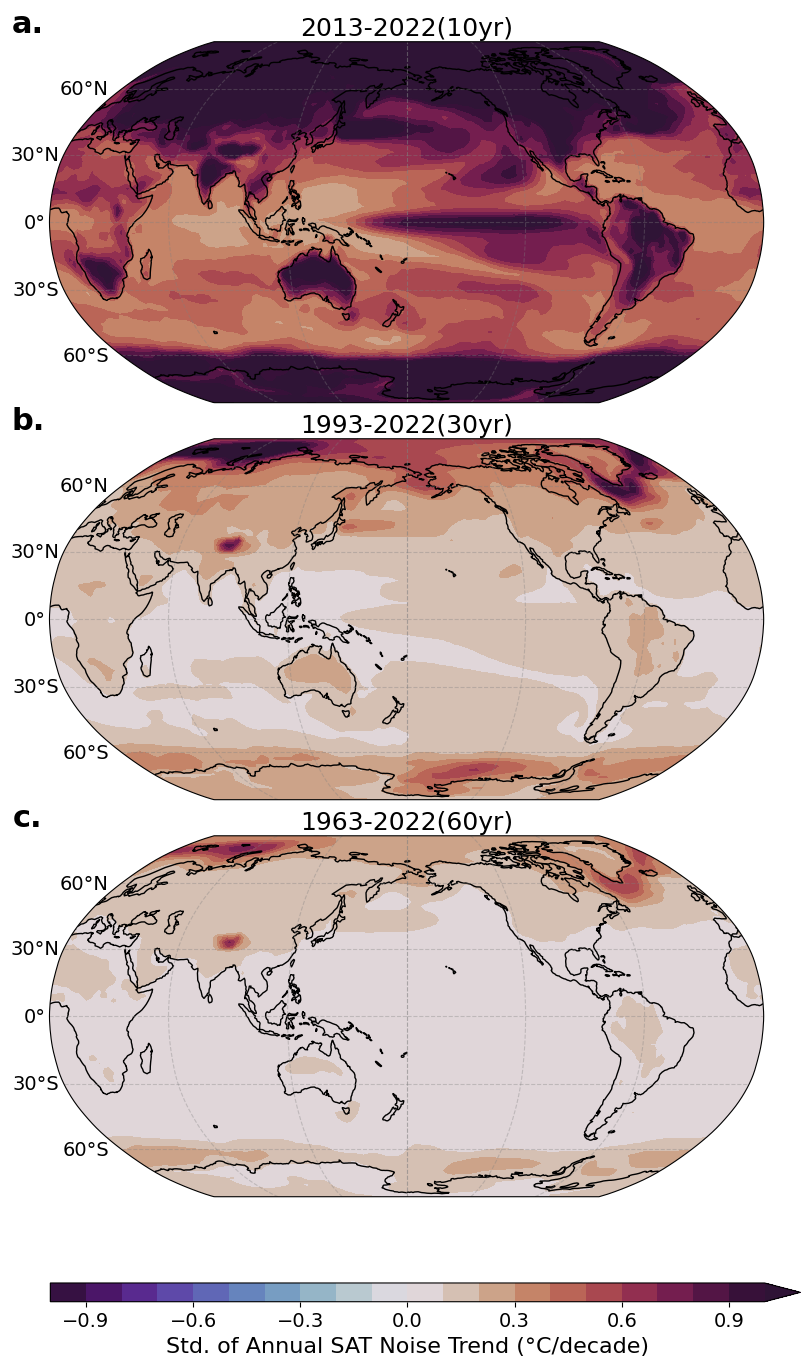

In [41]:
lat = MMEM_annual_noise_std['10yr'].lat
lon = MMEM_annual_noise_std['10yr'].lon
lat, lon 

titles = ["2013-2022(10yr)",  "1993-2022(30yr)", "1963-2022(60yr)"]
titles_left = ["a.", "b.", "c."]

import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable

# Define the GridSpec
fig = plt.figure(figsize=(25, 15))
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1], hspace=0.1)
extend='max'
periods = ["10yr", "30yr", "60yr"]
for j, period in enumerate(periods):
    # Define the axes
    ax = fig.add_subplot(gs[j], projection=ccrs.Robinson(180))
    is_left = (j % 3 == 0)
    is_bottom_row = j >= (len(periods)//3)*3 
    
    trend_data = MMEM_annual_noise_std[period]
    trend_with_cyclic, lon_with_cyclic = cutil.add_cyclic_point(trend_data, coord=lon)
    
    levels = np.arange(-1.0, 1.1, 0.1)
    contour_obj = plot_trend(trend_with_cyclic, lat, lon_with_cyclic, 
                    levels=levels, extend=extend, cmap='twilight_shifted',
                    # cmap=mcolors.ListedColormap(palettable.cmocean.diverging.Balance_20.mpl_colors),
                    title=titles[j], ax=ax, show_xticks = is_bottom_row, show_yticks = True)
    ax.text(-0.03, 1.05, titles_left[j], fontsize=22,weight='bold', ha='center', va='center', rotation='horizontal', transform=ax.transAxes)


# Add horizontal colorbars
cbar_ax = fig.add_axes([0.37, 0.04, 0.3, 0.0125])
cbar = plt.colorbar(contour_obj, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Std. of Annual SAT Noise Trend (°C/decade)', fontsize=16)

plt.tight_layout()
fig.savefig('MMEM_simulated_Noise_trend_Pattern_variations.png', dpi=300, bbox_inches='tight')

plt.show()

In [14]:
client.close()
scluster.close()